# Урок 15.9. Интегралы: площадь, накопление и вероятность

**Интерактивная версия:** `lessons/lesson_15_9/web/index.html`

После урока вы сможете:

- объяснять интеграл как накопление и площадь со знаком, вычислять суммы Римана с разными метками;
- находить предел сумм Римана для степеней вручную и объяснять интегрируемость через нижние и верхние суммы;
- применять свойства интеграла и находить среднее значение функции;
- формулировать основную теорему анализа $\frac{d}{dx}\int_a^x f = f$ и формулу Ньютона — Лейбница;
- находить первообразные по таблице, заменой, по частям, простейшими дробями — и проверять их;
- считать интегралы методами середин, трапеций, Симпсона и Монте-Карло и оценивать ошибку;
- исследовать несобственные интегралы на сходимость;
- вычислять площади между кривыми, коэффициент Джини, объёмы и длины дуг;
- выражать вероятности, средние и ожидаемые потери интегралами и находить лучшую константу;
- объяснять AUC, интегрированные градиенты и бустинг с малым темпом на языке интегралов.

Разделы ноутбука идут в том же порядке, что и 29 шагов урока (семь блоков). Каждое утверждение проверяется
числом, ключевые — сверкой с `scipy.integrate`, `scipy.special`, `scikit-learn` и учебной библиотекой `gbcourse`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation
from matplotlib.patches import Rectangle
from scipy import integrate, special

from gbcourse import datasets, metrics
from gbcourse.boosting import GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, VIOLET

use_course_style()
plt.rcParams["animation.embed_limit"] = 30

v = lambda t: 6 * t - 0.6 * t**2   # noqa: E731  скорость поездки, м/с
s = lambda t: 3 * t**2 - t**3 / 5  # noqa: E731  путь — её первообразная, м


def riemann(f, a, b, n, off=0.5):
    """Сумма Римана: off = 0 — левые концы, 0.5 — середины, 1 — правые; массив — свои метки в долях шага."""
    h = (b - a) / n
    return float(np.sum(f(a + (np.arange(n) + off) * h)) * h)


def trapezoid(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return float((b - a) / n * (y.sum() - (y[0] + y[-1]) / 2))


def simpson(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return float((b - a) / n / 3 * (y[0] + y[-1] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum()))

## Блок 1. Накопление и площадь

### Интуиция: бак с водой

Приток $r(t)$ (л/мин) задан ломаной; объём $V(t) = V_0 + \int_0^t r$. Где приток меняет знак, у объёма вершина
или впадина.

максимум объёма 22.333 л при t = 4.67 мин; приток там +0.002


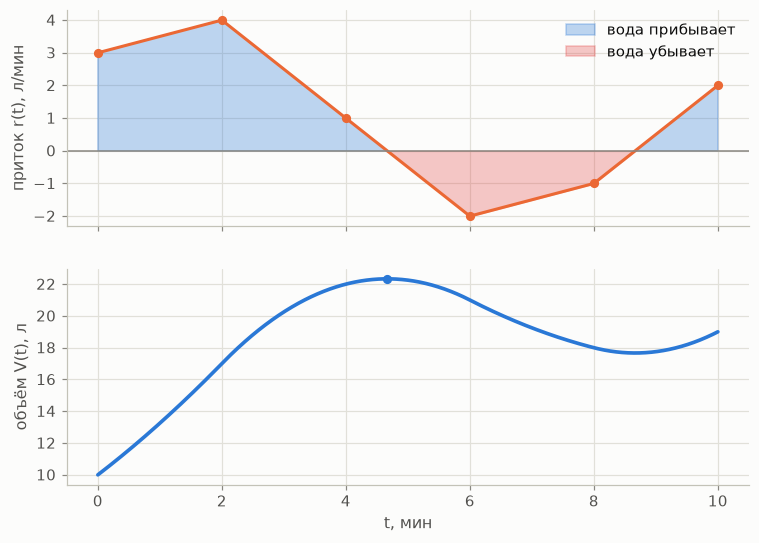

In [2]:
t_nodes = np.array([0, 2, 4, 6, 8, 10.0])
r_nodes = np.array([3, 4, 1, -2, -1, 2.0])
tt = np.linspace(0, 10, 2001)
r = np.interp(tt, t_nodes, r_nodes)
V = 10 + np.concatenate([[0], np.cumsum((r[1:] + r[:-1]) / 2 * np.diff(tt))])
i_max = np.argmax(V)
print(f"максимум объёма {V[i_max]:.3f} л при t = {tt[i_max]:.2f} мин; приток там {np.interp(tt[i_max], t_nodes, r_nodes):+.3f}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True)
a1.fill_between(tt, 0, r, where=r >= 0, color=BLUE, alpha=0.3, label="вода прибывает")
a1.fill_between(tt, 0, r, where=r < 0, color=RED, alpha=0.3, label="вода убывает")
a1.plot(t_nodes, r_nodes, "o-", color=ORANGE)
a1.axhline(0, color=MUTED, lw=1)
a1.set(ylabel="приток r(t), л/мин")
a1.legend()
a2.plot(tt, V, color=BLUE, lw=2.4)
a2.plot(tt[i_max], V[i_max], "o", color=BLUE)
a2.set(xlabel="t, мин", ylabel="объём V(t), л")
plt.show()

### Шаг 1. Путь по спидометру: показания раз в Δt

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Δt = 2    : слева   96.0000 м, справа   96.0000 м, середины  102.0000 м
Δt = 1    : слева   99.0000 м, справа   99.0000 м, середины  100.5000 м
Δt = 0.5  : слева   99.7500 м, справа   99.7500 м, середины  100.1250 м
Δt = 0.1  : слева   99.9900 м, справа   99.9900 м, середины  100.0050 м
Δt = 0.01 : слева   99.9999 м, справа   99.9999 м, середины  100.0001 м
точно s(10) − s(0) = 100.0 м


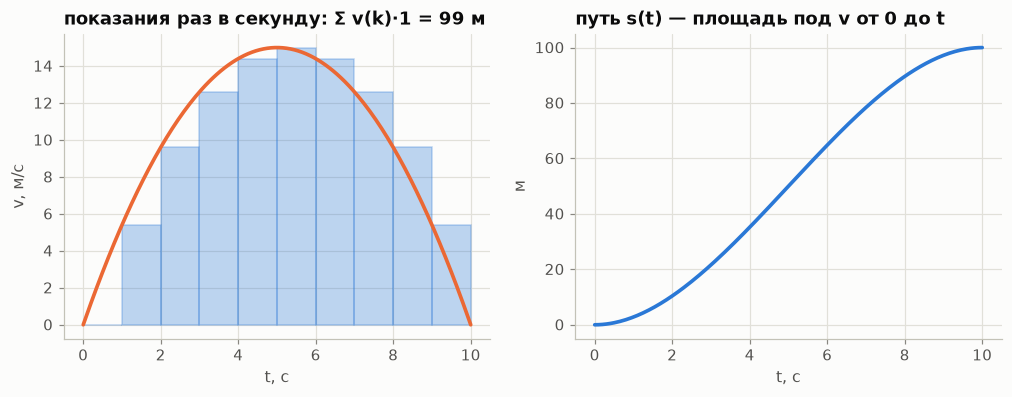

In [3]:
for dt in (2, 1, 0.5, 0.1, 0.01):
    n = round(10 / dt)
    print(f"Δt = {dt:<5}: слева {riemann(v, 0, 10, n, 0):9.4f} м, справа {riemann(v, 0, 10, n, 1):9.4f} м, середины {riemann(v, 0, 10, n):9.4f} м")
print("точно s(10) − s(0) =", s(10) - s(0), "м")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
t = np.linspace(0, 10, 201)
for k in range(10):
    a1.add_patch(Rectangle((k, 0), 1, v(k), color=BLUE, alpha=0.3, ec=BLUE))
a1.plot(t, v(t), color=ORANGE, lw=2.4)
a1.set(title="показания раз в секунду: Σ v(k)·1 = 99 м", xlabel="t, с", ylabel="v, м/с")
a2.plot(t, s(t), color=BLUE, lw=2.4)
a2.set(title="путь s(t) — площадь под v от 0 до t", xlabel="t, с", ylabel="м")
plt.show()

### Шаги 2–3. Геометрия и знак суммы Σ

Площади под прямыми — треугольники и трапеции; под полуокружностью — полкруга. Суммы Гаусса и квадратов —
основа для шага 5; отношение $\sum k^2 / n^3 \to \frac13$.

In [4]:
print("трапеция ∫₁³(2x + 1) =", (3 + 7) / 2 * 2, "; полукруг ∫₋₂²√(4 − x²) =", integrate.quad(lambda x: np.sqrt(4 - x**2), -2, 2)[0], "= 2π =", 2 * np.pi)
for n in (10, 100, 1000):
    k = np.arange(1, n + 1)
    assert k.sum() == n * (n + 1) // 2 and (k**2).sum() == n * (n + 1) * (2 * n + 1) // 6
    print(f"n = {n:4d}: Σk = {k.sum()}, Σk² = {(k**2).sum()}, Σk²/n³ = {(k**2).sum() / n**3:.7f}")

трапеция ∫₁³(2x + 1) = 10.0 ; полукруг ∫₋₂²√(4 − x²) = 6.283185307179593 = 2π = 6.283185307179586
n =   10: Σk = 55, Σk² = 385, Σk²/n³ = 0.3850000
n =  100: Σk = 5050, Σk² = 338350, Σk²/n³ = 0.3383500
n = 1000: Σk = 500500, Σk² = 333833500, Σk²/n³ = 0.3338335


### Шаг 4. Суммы Римана (анимация) и случайные метки

In [5]:
sq = lambda x: x**2  # noqa: E731
rng = Mulberry32(1)
for n in (4, 10, 100, 1000):
    tags = np.array([rng.random() for _ in range(n)])
    print(f"n = {n:4d}: слева {riemann(sq, 0, 2, n, 0):.5f}, середина {riemann(sq, 0, 2, n):.6f}, справа {riemann(sq, 0, 2, n, 1):.5f}, случайно {riemann(sq, 0, 2, n, tags):.5f}")
print("1/x на [1, 2], n = 4: слева", round(riemann(lambda x: 1 / x, 1, 2, 4, 0), 4), "справа", round(riemann(lambda x: 1 / x, 1, 2, 4, 1), 4),
      "середины", round(riemann(lambda x: 1 / x, 1, 2, 4), 5), "; ln 2 =", round(math.log(2), 5))

ns = [1, 2, 3, 4, 6, 8, 12, 16, 25, 40, 64]
xs = np.linspace(0, 2, 200)
fig, ax = plt.subplots(figsize=(6.5, 3.8), dpi=72)


def frame(i):
    n = ns[i]
    h = 2 / n
    ax.clear()
    for k in range(n):
        ax.add_patch(Rectangle((k * h, 0), h, sq(k * h), color=BLUE, alpha=0.3, lw=0.5, ec=BLUE))
    ax.plot(xs, sq(xs), color=ORANGE, lw=2.4)
    ax.set(xlim=(0, 2.05), ylim=(0, 4.2), title=f"n = {n}: левая сумма {riemann(sq, 0, 2, n, 0):.4f} (точно 2.6667)")
    return []


anim = animation.FuncAnimation(fig, frame, frames=len(ns), interval=700)
plt.close(fig)
display(HTML(anim.to_jshtml()))

n =    4: слева 1.75000, середина 2.625000, справа 3.75000, случайно 2.95443
n =   10: слева 2.28000, середина 2.660000, справа 3.08000, случайно 2.64960
n =  100: слева 2.62680, середина 2.666600, справа 2.70680, случайно 2.66559
n = 1000: слева 2.66267, середина 2.666666, справа 2.67067, случайно 2.66671
1/x на [1, 2], n = 4: слева 0.7595 справа 0.6345 середины 0.69122 ; ln 2 = 0.69315


### Шаг 5. Предел сумм Римана вручную

Для $x^2$ на $[0, b]$ правые суммы $S_n = \frac{b^3}{3}\left(1 + \frac1n\right)\left(1 + \frac1{2n}\right)$; ошибка
$\approx \frac{b^3}{2n}$, поэтому ошибка × n почти постоянна.

In [6]:
b = 2.0
for n in (1, 10, 100, 1000):
    direct = riemann(sq, 0, b, n, 1)
    formula = b**3 / 3 * (1 + 1 / n) * (1 + 1 / (2 * n))
    print(f"n = {n:4d}: Σ = {direct:.6f}, формула {formula:.6f}, ошибка × n = {(direct - b**3 / 3) * n:.4f}")
    assert abs(direct - formula) < 1e-12

n =    1: Σ = 8.000000, формула 8.000000, ошибка × n = 5.3333
n =   10: Σ = 3.080000, формула 3.080000, ошибка × n = 4.1333
n =  100: Σ = 2.706800, формула 2.706800, ошибка × n = 4.0133
n = 1000: Σ = 2.670668, формула 2.670668, ошибка × n = 4.0013


### Шаг 6. Нижние и верхние суммы

Для возрастающей $x^2$ на $[0, 2]$ зазор $U_n - L_n = \frac8n$; для ступеньки со скачком 1.5 — $1.5\,h$.

In [7]:
def darboux(f, a, b, n, m=200):
    edges = np.linspace(a, b, n + 1)
    lo = np.array([f(np.linspace(edges[i], edges[i + 1], m)).min() for i in range(n)])
    hi = np.array([f(np.linspace(edges[i], edges[i + 1], m)).max() for i in range(n)])
    h = (b - a) / n
    return lo.sum() * h, hi.sum() * h


step = lambda x: np.where(x < 1.5, 1.0, 2.5)  # noqa: E731
for n in (4, 16, 64):
    L, U = darboux(sq, 0, 2, n)
    Ls, Us = darboux(step, 0, 3, n)
    print(f"n = {n:2d}: x² → L = {L:.4f}, U = {U:.4f}, U − L = {U - L:.4f} (8/n = {8 / n:.4f});  ступенька: U − L = {Us - Ls:.4f}")

n =  4: x² → L = 1.7500, U = 3.7500, U − L = 2.0000 (8/n = 2.0000);  ступенька: U − L = 1.1250
n = 16: x² → L = 2.4219, U = 2.9219, U − L = 0.5000 (8/n = 0.5000);  ступенька: U − L = 0.2812
n = 64: x² → L = 2.6045, U = 2.7295, U − L = 0.1250 (8/n = 0.1250);  ступенька: U − L = 0.0703


## Блок 2. Свойства интеграла

### Шаги 7–9. Знак, свойства, среднее значение

In [8]:
quad = lambda f, a, b: integrate.quad(f, a, b, limit=200)[0]  # noqa: E731
print("∫₀³(x − 1) =", round(quad(lambda x: x - 1, 0, 3), 6), "; ∫₀³|x − 1| =", round(quad(lambda x: abs(x - 1), 0, 3), 6))
print("перемещение ∫₀⁴(4 − 2t) =", round(quad(lambda t: 4 - 2 * t, 0, 4), 6), "; путь ∫₀⁴|4 − 2t| =", round(quad(lambda t: abs(4 - 2 * t), 0, 4), 6))
print("∫₋₁¹(x³ − x) =", round(quad(lambda x: x**3 - x, -1, 1), 12), "; ∫₋₁¹|x³ − x| =", round(quad(lambda x: abs(x**3 - x), -1, 1), 6))
print("склейка: ∫₀³x² − ∫₀¹x² =", 9 - 1 / 3, "=", quad(sq, 1, 3))
I_g = quad(lambda x: np.exp(-x**2), 0, 1)
print(f"оценка: e⁻¹ = {math.exp(-1):.4f} ≤ 2/3 ≤ ∫₀¹ e^(−x²) = {I_g:.4f} ≤ 1")
mean_v = quad(v, 0, 10) / 10
c = np.roots([-0.6, 6, -mean_v])
print("средняя скорость:", mean_v, "м/с; достигается при t =", np.sort(c).round(3))

∫₀³(x − 1) = 1.5 ; ∫₀³|x − 1| = 2.5
перемещение ∫₀⁴(4 − 2t) = -0.0 ; путь ∫₀⁴|4 − 2t| = 8.0
∫₋₁¹(x³ − x) = 0.0 ; ∫₋₁¹|x³ − x| = 0.5
склейка: ∫₀³x² − ∫₀¹x² = 8.666666666666666 = 8.666666666666668
оценка: e⁻¹ = 0.3679 ≤ 2/3 ≤ ∫₀¹ e^(−x²) = 0.7468 ≤ 1
средняя скорость: 10.0 м/с; достигается при t = [2.113 7.887]


## Блок 3. Основная теорема анализа

### Шаги 10–11. Функция накопления и $A'(x) = f(x)$

минимум A = ∫₀ˣ(t² − 1)dt при x = 1.0000 (корень f), A = -0.66667 (точно −2/3)
max |A′ − f| = 9.908163178806717e-11
h = 1     : min f = 1.000000 ≤ ΔA/h = 2.333333 ≤ max f = 4.000000
h = 0.1   : min f = 1.000000 ≤ ΔA/h = 1.103333 ≤ max f = 1.210000
h = 0.01  : min f = 1.000000 ≤ ΔA/h = 1.010033 ≤ max f = 1.020100
h = 0.001 : min f = 1.000000 ≤ ΔA/h = 1.001000 ≤ max f = 1.002001
d/dx ∫₁^{x²} ln t dt при x = 1.7: 3.6082721072583364 ; 4x ln x = 3.6082721072227586


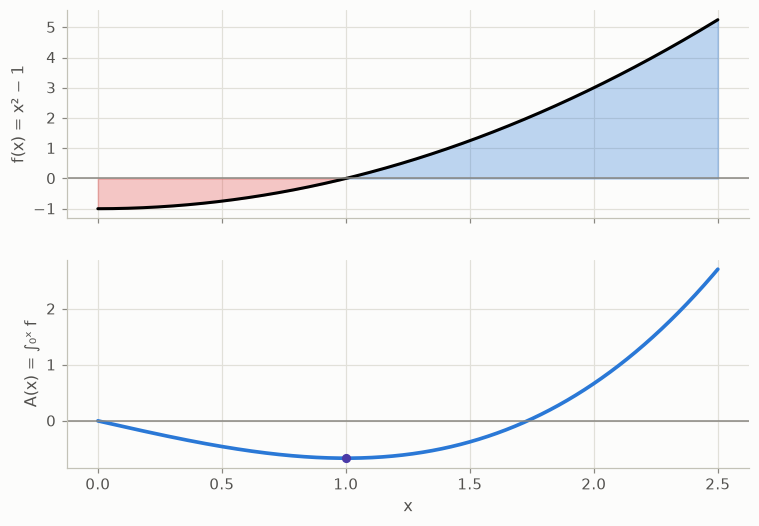

In [9]:
x = np.linspace(0, 2.5, 250001)
f = x**2 - 1
A = np.concatenate([[0], np.cumsum((f[1:] + f[:-1]) / 2 * np.diff(x))])
dA = np.gradient(A, x)
i_min = np.argmin(A)
print(f"минимум A = ∫₀ˣ(t² − 1)dt при x = {x[i_min]:.4f} (корень f), A = {A[i_min]:.5f} (точно −2/3)")
print("max |A′ − f| =", np.abs(dA[10:-10] - f[10:-10]).max())

for h in (1, 0.1, 0.01, 0.001):
    tt = np.linspace(1, 1 + h, 1001)
    ratio = ((1 + h)**3 / 3 - 1 / 3) / h
    print(f"h = {h:<6}: min f = {tt.min()**2:.6f} ≤ ΔA/h = {ratio:.6f} ≤ max f = {tt.max()**2:.6f}")

# переменный верхний предел: d/dx ∫₁^{x²} ln t dt = 4x ln x
G = lambda x: quad(np.log, 1, x**2)  # noqa: E731
x0, e = 1.7, 1e-5
print("d/dx ∫₁^{x²} ln t dt при x = 1.7:", (G(x0 + e) - G(x0 - e)) / (2 * e), "; 4x ln x =", 4 * x0 * math.log(x0))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5.4), sharex=True)
a1.fill_between(x, 0, f, where=f < 0, color=RED, alpha=0.3)
a1.fill_between(x, 0, f, where=f >= 0, color=BLUE, alpha=0.3)
a1.plot(x, f, color="black", lw=2)
a1.axhline(0, color=MUTED, lw=1)
a1.set(ylabel="f(x) = x² − 1")
a2.plot(x, A, color=BLUE, lw=2.4)
a2.plot([1], [-2 / 3], "o", color=VIOLET)
a2.axhline(0, color=MUTED, lw=1)
a2.set(xlabel="x", ylabel="A(x) = ∫₀ˣ f")
plt.show()

### Шаги 12–13. Первообразные и формула Ньютона — Лейбница

In [10]:
cases = [
    ("x² на [0, 2]", sq, lambda x: x**3 / 3, 0, 2),
    ("sin на [0, π]", np.sin, lambda x: -np.cos(x), 0, np.pi),
    ("1/x на [1, e]", lambda x: 1 / x, np.log, 1, np.e),
    ("v(t) на [0, 10]", v, s, 0, 10),
    ("x² − 2x + 3 на [−1, 2]", lambda x: x**2 - 2 * x + 3, lambda x: x**3 / 3 - x**2 + 3 * x, -1, 2),
]
for name, f_, F_, a, b in cases:
    print(f"{name:24} quad {quad(f_, a, b):.10f}   F(b) − F(a) = {F_(b) - F_(a):.10f}")
print("начальное условие: F′ = cos, F(0) = 2 → F = sin x + 2; F(π/2) =", math.sin(math.pi / 2) + 2)

x² на [0, 2]             quad 2.6666666667   F(b) − F(a) = 2.6666666667
sin на [0, π]            quad 2.0000000000   F(b) − F(a) = 2.0000000000
1/x на [1, e]            quad 1.0000000000   F(b) − F(a) = 1.0000000000
v(t) на [0, 10]          quad 100.0000000000   F(b) − F(a) = 100.0000000000
x² − 2x + 3 на [−1, 2]   quad 9.0000000000   F(b) − F(a) = 9.0000000000
начальное условие: F′ = cos, F(0) = 2 → F = sin x + 2; F(π/2) = 3.0


## Блок 4. Техника интегрирования

### Шаги 14–17. Все примеры решателя: численная площадь против $F(b) - F(a)$

Если найденная первообразная верна, разность $F(b) - F(a)$ совпадает с `scipy.integrate.quad` до ошибок
округления. Последний пример — $e^{-x^2}$ — через функцию ошибок `scipy.special.erf`.

In [11]:
sig = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
examples = [
    ("3x² − 4x + 5", lambda x: 3 * x**2 - 4 * x + 5, lambda x: x**3 - 2 * x**2 + 5 * x, 0, 2),
    ("√x + 1/x²", lambda x: np.sqrt(x) + x**-2, lambda x: 2 / 3 * x**1.5 - 1 / x, 1, 4),
    ("(x + 1)²/x", lambda x: (x + 1)**2 / x, lambda x: x**2 / 2 + 2 * x + np.log(x), 1, 3),
    ("e^(3x)", lambda x: np.exp(3 * x), lambda x: np.exp(3 * x) / 3, 0, 1),
    ("2ˣ", lambda x: 2**x, lambda x: 2**x / np.log(2), 0, 3),
    ("σ(x) → softplus", sig, lambda x: np.log1p(np.exp(x)), -2, 2),
    ("tg² x", lambda x: np.tan(x)**2, lambda x: np.tan(x) - x, 0, np.pi / 4),
    ("2x·e^(x²)", lambda x: 2 * x * np.exp(x**2), lambda x: np.exp(x**2), 0, 1),
    ("(3x + 1)⁵", lambda x: (3 * x + 1)**5, lambda x: (3 * x + 1)**6 / 18, 0, 1),
    ("x/(1 + x²)", lambda x: x / (1 + x**2), lambda x: 0.5 * np.log(1 + x**2), 0, 1),
    ("tg x", np.tan, lambda x: -np.log(np.cos(x)), 0, np.pi / 3),
    ("2x·cos(x²)", lambda x: 2 * x * np.cos(x**2), lambda x: np.sin(x**2), 0, np.sqrt(np.pi / 2)),
    ("ln x / x", lambda x: np.log(x) / x, lambda x: np.log(x)**2 / 2, 1, np.e),
    ("x√(1 − x²)", lambda x: x * np.sqrt(1 - x**2), lambda x: -(1 - x**2)**1.5 / 3, 0, 1),
    ("eˣ/(1 + eˣ)² = σ′", lambda x: np.exp(x) / (1 + np.exp(x))**2, sig, -3, 3),
    ("x·eˣ", lambda x: x * np.exp(x), lambda x: (x - 1) * np.exp(x), 0, 1),
    ("x·cos x", lambda x: x * np.cos(x), lambda x: x * np.sin(x) + np.cos(x), 0, np.pi / 2),
    ("ln x", np.log, lambda x: x * np.log(x) - x, 1, np.e),
    ("x·e^(−x)", lambda x: x * np.exp(-x), lambda x: -(x + 1) * np.exp(-x), 0, 1),
    ("x²·eˣ", lambda x: x**2 * np.exp(x), lambda x: (x**2 - 2 * x + 2) * np.exp(x), 0, 1),
    ("eˣ·sin x", lambda x: np.exp(x) * np.sin(x), lambda x: np.exp(x) * (np.sin(x) - np.cos(x)) / 2, 0, np.pi),
    ("arctg x", np.arctan, lambda x: x * np.arctan(x) - 0.5 * np.log(1 + x**2), 0, 1),
    ("1/(x − 2)", lambda x: 1 / (x - 2), lambda x: np.log(np.abs(x - 2)), 3, 5),
    ("1/(x(x + 1))", lambda x: 1 / (x * (x + 1)), lambda x: np.log(x / (x + 1)), 1, 2),
    ("1/(x² − 1)", lambda x: 1 / (x**2 - 1), lambda x: 0.5 * np.log((x - 1) / (x + 1)), 2, 3),
    ("(2x + 3)/(x² + 3x + 2)", lambda x: (2 * x + 3) / (x**2 + 3 * x + 2), lambda x: np.log(x**2 + 3 * x + 2), 0, 1),
    ("1/(x² + 4)", lambda x: 1 / (x**2 + 4), lambda x: 0.5 * np.arctan(x / 2), 0, 2),
    ("1/(y(1 − y)) → логит", lambda y: 1 / (y * (1 - y)), lambda y: np.log(y / (1 - y)), 0.2, 0.8),
    ("e^(−x²) → erf", lambda x: np.exp(-x**2), lambda x: np.sqrt(np.pi) / 2 * special.erf(x), 0, 1),
]
worst = 0.0
for name, f_, F_, a, b in examples:
    num, d = quad(f_, a, b), F_(b) - F_(a)
    worst = max(worst, abs(num - d))
    print(f"{name:24} [{a:.3g}, {b:.3g}]: quad {num:12.8f}   F(b) − F(a) {d:12.8f}")
print("наибольшее расхождение:", f"{worst:.1e}")
assert worst < 1e-8

3x² − 4x + 5             [0, 2]: quad  10.00000000   F(b) − F(a)  10.00000000
√x + 1/x²                [1, 4]: quad   5.41666667   F(b) − F(a)   5.41666667
(x + 1)²/x               [1, 3]: quad   9.09861229   F(b) − F(a)   9.09861229
e^(3x)                   [0, 1]: quad   6.36184564   F(b) − F(a)   6.36184564
2ˣ                       [0, 3]: quad  10.09886529   F(b) − F(a)  10.09886529
σ(x) → softplus          [-2, 2]: quad   2.00000000   F(b) − F(a)   2.00000000
tg² x                    [0, 0.785]: quad   0.21460184   F(b) − F(a)   0.21460184
2x·e^(x²)                [0, 1]: quad   1.71828183   F(b) − F(a)   1.71828183
(3x + 1)⁵                [0, 1]: quad 227.50000000   F(b) − F(a) 227.50000000
x/(1 + x²)               [0, 1]: quad   0.34657359   F(b) − F(a)   0.34657359
tg x                     [0, 1.05]: quad   0.69314718   F(b) − F(a)   0.69314718
2x·cos(x²)               [0, 1.25]: quad   1.00000000   F(b) − F(a)   1.00000000
ln x / x                 [1, 2.72]: quad   0.50000000

## Блок 5. Численные методы и несобственные интегралы

### Шаги 18–19. Три метода, порядок точности, правило Рунге и Ричардсон

n = 2 вручную: трапеции 1.75393  середины 1.70051  Симпсон 1.71886
середина : n = 16 → 2.796e-04; наблюдаемый порядок log₂(eₙ/e₂ₙ) = 2.000
трапеции : n = 16 → 5.593e-04; наблюдаемый порядок log₂(eₙ/e₂ₙ) = 2.000
Симпсон  : n = 16 → 1.456e-07; наблюдаемый порядок log₂(eₙ/e₂ₙ) = 3.999
Рунге: (T₁₆ − T₈)/3 = -5.5915e-04, настоящая ошибка T₁₆ = +5.5930e-04; Ричардсон: +1.46e-07
предсказание (b − a)h²·f″/12: 0.000559336532701512
нужно узлов для 10⁻⁶: трапеции 379  середины 268  Симпсон 10
scipy.integrate.quad: 1.718281828459045 (оценка ошибки 1.9e-14); точно 1.718281828459045
scipy trapezoid/simpson на 17 узлах: 0.000559300120949402 1.4559284666759709e-07


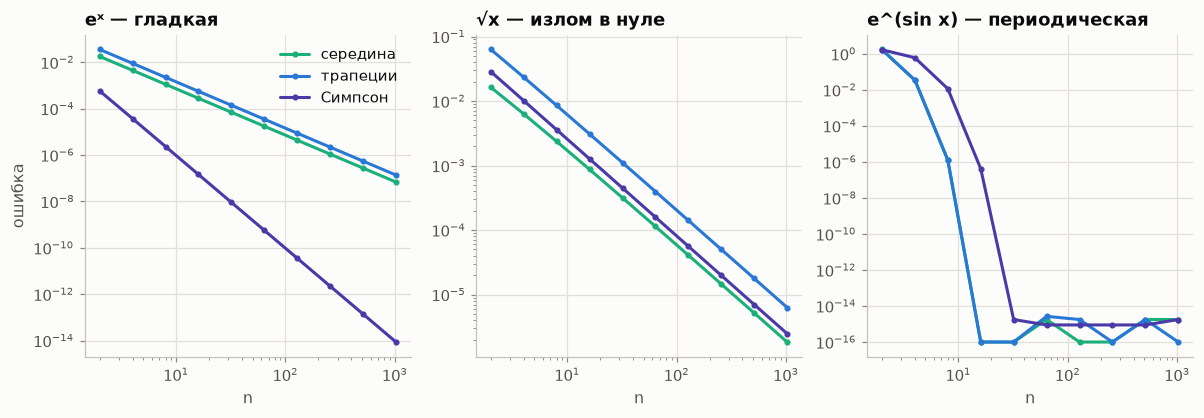

In [12]:
exact = math.e - 1
print("n = 2 вручную: трапеции", round(trapezoid(np.exp, 0, 1, 2), 5), " середины", round(riemann(np.exp, 0, 1, 2), 5), " Симпсон", round(simpson(np.exp, 0, 1, 2), 5))
ns2 = np.array([2, 4, 8, 16, 32, 64, 128])
errs = {
    "середина": np.array([abs(riemann(np.exp, 0, 1, n) - exact) for n in ns2]),
    "трапеции": np.array([abs(trapezoid(np.exp, 0, 1, n) - exact) for n in ns2]),
    "Симпсон": np.array([abs(simpson(np.exp, 0, 1, n) - exact) for n in ns2]),
}
for name, e in errs.items():
    print(f"{name:9}: n = 16 → {e[3]:.3e}; наблюдаемый порядок log₂(eₙ/e₂ₙ) = {np.log2(e[3] / e[4]):.3f}")
t8, t16 = trapezoid(np.exp, 0, 1, 8), trapezoid(np.exp, 0, 1, 16)
print(f"Рунге: (T₁₆ − T₈)/3 = {(t16 - t8) / 3:+.4e}, настоящая ошибка T₁₆ = {t16 - exact:+.4e}; Ричардсон: {(4 * t16 - t8) / 3 - exact:+.2e}")
print("предсказание (b − a)h²·f″/12:", (1 / 12) * (1 / 16**2) * (math.e - 1))
need = lambda method, step=1: next(n for n in range(step, 10000, step) if abs(method(np.exp, 0, 1, n) - exact) < 1e-6)  # noqa: E731
print("нужно узлов для 10⁻⁶: трапеции", need(trapezoid), " середины", need(riemann), " Симпсон", need(simpson, 2))
val, est = integrate.quad(np.exp, 0, 1)
print(f"scipy.integrate.quad: {val:.15f} (оценка ошибки {est:.1e}); точно {exact:.15f}")
xg = np.linspace(0, 1, 17)
print("scipy trapezoid/simpson на 17 узлах:", integrate.trapezoid(np.exp(xg), xg) - exact, integrate.simpson(np.exp(xg), x=xg) - exact)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
ns3 = 2 ** np.arange(1, 11)
for ax, (title, f_, a, b, ex) in zip(axs, [("eˣ — гладкая", np.exp, 0, 1, exact), ("√x — излом в нуле", np.sqrt, 0, 1, 2 / 3),
                                           ("e^(sin x) — периодическая", lambda x: np.exp(np.sin(x)), 0, 2 * np.pi, 2 * np.pi * special.i0(1))]):
    for meth, c, name in [(riemann, AQUA, "середина"), (trapezoid, BLUE, "трапеции"), (simpson, VIOLET, "Симпсон")]:
        ax.loglog(ns3, [max(abs(meth(f_, a, b, n) - ex), 1e-16) for n in ns3], "o-", color=c, ms=3, label=name)
    ax.set(title=title, xlabel="n")
axs[0].set_ylabel("ошибка")
axs[0].legend()
plt.show()

### Шаг 20. Монте-Карло: ошибка ~ σ/√n и не зависит от размерности

In [13]:
rng = Mulberry32(3)
X = np.array([rng.random() for _ in range(20000)])
Y = np.array([rng.random() for _ in range(20000)])
for n in (100, 1000, 10000, 20000):
    hit = 4 * np.mean(Y[:n] <= np.sqrt(1 - X[:n]**2))
    mean = 4 * np.mean(np.sqrt(1 - X[:n]**2))
    print(f"n = {n:5d}: π ≈ {hit:.4f} (попадания), {mean:.4f} (среднее); σ/√n для попаданий ≈ {4 * math.sqrt(math.pi / 4 * (1 - math.pi / 4) / n):.4f}")

gen = np.random.default_rng(0)
n = 100_000
for d in (1, 2, 5, 10):
    k = int(round(n ** (1 / d)))
    if k**d > 1.5 * n:
        k -= 1
    g = (np.arange(k) + 0.5) / k
    grid = np.mean(np.pi / 2 * np.sin(np.pi * g)) ** d
    mc = np.mean(np.prod(np.pi / 2 * np.sin(np.pi * gen.random((n, d))), axis=1))
    print(f"d = {d:2d}: сетка {k:6d}^{d} — ошибка {abs(grid - 1):.1e};  Монте-Карло 10⁵ точек — ошибка {abs(mc - 1):.1e}")

n =   100: π ≈ 3.2000 (попадания), 3.0246 (среднее); σ/√n для попаданий ≈ 0.1642
n =  1000: π ≈ 3.2520 (попадания), 3.1493 (среднее); σ/√n для попаданий ≈ 0.0519
n = 10000: π ≈ 3.1392 (попадания), 3.1432 (среднее); σ/√n для попаданий ≈ 0.0164
n = 20000: π ≈ 3.1478 (попадания), 3.1354 (среднее); σ/√n для попаданий ≈ 0.0116
d =  1: сетка 100000^1 — ошибка 4.1e-11;  Монте-Карло 10⁵ точек — ошибка 9.3e-04
d =  2: сетка    316^2 — ошибка 8.2e-06;  Монте-Карло 10⁵ точек — ошибка 1.8e-03
d =  5: сетка     10^5 — ошибка 2.1e-02;  Монте-Карло 10⁵ точек — ошибка 1.2e-02
d = 10: сетка      3^10 — ошибка 5.9e-01;  Монте-Карло 10⁵ точек — ошибка 7.7e-03


### Шаги 21–22. Несобственные интегралы

In [14]:
for T in (2, 10, 100, 1000):
    print(f"T = {T:5d}: ∫₀ᵀ e^(−x) = {1 - math.exp(-T):.6f}, ∫₁ᵀ 1/x² = {1 - 1 / T:.4f}, ∫₁ᵀ 1/x = {math.log(T):.4f}, ∫₀ᵀ 1/(1 + x²) = {math.atan(T):.6f}")
inf_cases = [
    ("e^(−x), [0, ∞)", lambda x: np.exp(-x), 0, np.inf, 1),
    ("1/(1 + x²), [0, ∞)", lambda x: 1 / (1 + x**2), 0, np.inf, np.pi / 2),
    ("x·e^(−x), [0, ∞)", lambda x: x * np.exp(-x), 0, np.inf, 1),
    ("1/(x² + x), [1, ∞)", lambda x: 1 / (x**2 + x), 1, np.inf, math.log(2)),
    ("e^(−x²), [0, ∞)", lambda x: np.exp(-x**2), 0, np.inf, math.sqrt(math.pi) / 2),
    ("1/√x, (0, 1]", lambda x: 1 / np.sqrt(x), 0, 1, 2),
    ("ln x, (0, 1]", np.log, 0, 1, -1),
]
for name, f_, a, b, ex in inf_cases:
    print(f"{name:20} quad = {integrate.quad(f_, a, b)[0]:.10f}, ожидалось {ex:.10f}")
for p in (0.5, 1.5, 2, 3):
    tail = f"{1 / (p - 1):.4f}" if p > 1 else "расходится"
    zero = f"{1 / (1 - p):.4f}" if p < 1 else "расходится"
    print(f"p = {p}: ∫₁^∞ x^(−p) = {tail};  ∫₀¹ x^(−p) = {zero}")

T =     2: ∫₀ᵀ e^(−x) = 0.864665, ∫₁ᵀ 1/x² = 0.5000, ∫₁ᵀ 1/x = 0.6931, ∫₀ᵀ 1/(1 + x²) = 1.107149
T =    10: ∫₀ᵀ e^(−x) = 0.999955, ∫₁ᵀ 1/x² = 0.9000, ∫₁ᵀ 1/x = 2.3026, ∫₀ᵀ 1/(1 + x²) = 1.471128
T =   100: ∫₀ᵀ e^(−x) = 1.000000, ∫₁ᵀ 1/x² = 0.9900, ∫₁ᵀ 1/x = 4.6052, ∫₀ᵀ 1/(1 + x²) = 1.560797
T =  1000: ∫₀ᵀ e^(−x) = 1.000000, ∫₁ᵀ 1/x² = 0.9990, ∫₁ᵀ 1/x = 6.9078, ∫₀ᵀ 1/(1 + x²) = 1.569796
e^(−x), [0, ∞)       quad = 1.0000000000, ожидалось 1.0000000000
1/(1 + x²), [0, ∞)   quad = 1.5707963268, ожидалось 1.5707963268
x·e^(−x), [0, ∞)     quad = 1.0000000000, ожидалось 1.0000000000
1/(x² + x), [1, ∞)   quad = 0.6931471806, ожидалось 0.6931471806
e^(−x²), [0, ∞)      quad = 0.8862269255, ожидалось 0.8862269255
1/√x, (0, 1]         quad = 2.0000000000, ожидалось 2.0000000000
ln x, (0, 1]         quad = -1.0000000000, ожидалось -1.0000000000
p = 0.5: ∫₁^∞ x^(−p) = расходится;  ∫₀¹ x^(−p) = 2.0000
p = 1.5: ∫₁^∞ x^(−p) = 2.0000;  ∫₀¹ x^(−p) = расходится
p = 2: ∫₁^∞ x^(−p) = 1.0000;  ∫₀¹ x^(−p) = 

## Блок 6. Геометрия и физика

### Шаги 23–24. Между кривыми, Джини, объёмы, длины дуг

In [15]:
print("∫₀¹(x − x²) =", quad(lambda x: x - x**2, 0, 1), "= 1/6")
print("∫₋₁²(x + 2 − x²) =", quad(lambda x: x + 2 - x**2, -1, 2))
print("∫₀^π|sin − cos| =", quad(lambda x: abs(np.sin(x) - np.cos(x)), 0, np.pi), "= 2√2 =", 2 * math.sqrt(2))
for k in (2, 3, 5):
    print(f"Лоренц L = p^{k}: Джини = {1 - 2 * quad(lambda p, k=k: p**k, 0, 1):.4f} = (k − 1)/(k + 1) = {(k - 1) / (k + 1):.4f}")
vols = [("конус", lambda x: x / 2, 0, 4, 16 * math.pi / 3), ("параболоид", np.sqrt, 0, 4, 8 * math.pi),
        ("шар", lambda x: np.sqrt(4 - x**2), -2, 2, 32 * math.pi / 3), ("ваза", lambda x: 1 + 0.5 * np.sin(x), 0, 2 * math.pi, 2.25 * math.pi**2)]
for name, f_, a, b, ex in vols:
    disks = math.pi * riemann(lambda x, f_=f_: f_(x)**2, a, b, 16)
    print(f"{name:10}: 16 дисков {disks:9.4f}, π∫f² = {math.pi * quad(lambda x, f_=f_: f_(x)**2, a, b):9.4f}, формула {ex:9.4f}")
print("длина параболы:", quad(lambda x: np.sqrt(1 + 4 * x**2), 0, 1), "; синусоиды:", quad(lambda x: np.sqrt(1 + np.cos(x)**2), 0, np.pi))
print("работа пружины k = 100 Н/м, L = 0.1 м:", quad(lambda x: 100 * x, 0, 0.1), "Дж = kL²/2 =", 100 * 0.01 / 2)

∫₀¹(x − x²) = 0.16666666666666666 = 1/6
∫₋₁²(x + 2 − x²) = 4.5
∫₀^π|sin − cos| = 2.82842712474619 = 2√2 = 2.8284271247461903
Лоренц L = p^2: Джини = 0.3333 = (k − 1)/(k + 1) = 0.3333
Лоренц L = p^3: Джини = 0.5000 = (k − 1)/(k + 1) = 0.5000
Лоренц L = p^5: Джини = 0.6667 = (k − 1)/(k + 1) = 0.6667
конус     : 16 дисков   16.7388, π∫f² =   16.7552, формула   16.7552
параболоид: 16 дисков   25.1327, π∫f² =   25.1327, формула   25.1327
шар       : 16 дисков   33.5758, π∫f² =   33.5103, формула   33.5103
ваза      : 16 дисков   22.2066, π∫f² =   22.2066, формула   22.2066
длина параболы: 1.4789428575445973 ; синусоиды: 3.8201977890277115
работа пружины k = 100 Н/м, L = 0.1 м: 0.5 Дж = kL²/2 = 0.5


## Блок 7. Вероятность и машинное обучение

### Шаг 25. Плотность и функция распределения

In [16]:
pdf = lambda z: np.exp(-z**2 / 2) / np.sqrt(2 * np.pi)  # noqa: E731
Phi = lambda z: 0.5 * (1 + special.erf(z / np.sqrt(2)))  # noqa: E731
for k in (1, 2, 3):
    print(f"P(|Z| ≤ {k}) = {simpson(pdf, -k, k, 2000):.4%} = Φ({k}) − Φ(−{k}) = {Phi(k) - Phi(-k):.4%}")
print("вся площадь:", round(integrate.quad(pdf, -np.inf, np.inf)[0], 12), "; Φ′(0.7) численно:", (Phi(0.7 + 1e-6) - Phi(0.7 - 1e-6)) / 2e-6, "= p(0.7) =", pdf(0.7))
lam = 0.5
print("экспоненциальное λ = 0.5: P(X > 3) =", math.exp(-1.5), "; медиана ln2/λ =", math.log(2) / lam)

P(|Z| ≤ 1) = 68.2689% = Φ(1) − Φ(−1) = 68.2689%
P(|Z| ≤ 2) = 95.4500% = Φ(2) − Φ(−2) = 95.4500%
P(|Z| ≤ 3) = 99.7300% = Φ(3) − Φ(−3) = 99.7300%
вся площадь: 1.0 ; Φ′(0.7) численно: 0.31225393343214947 = p(0.7) = 0.31225393336676127
экспоненциальное λ = 0.5: P(X > 3) = 0.22313016014842982 ; медиана ln2/λ = 1.3862943611198906


### Шаг 26. Ожидаемые потери и лучшая константа

$R(c) = \int L(y, c)\,p(y)\,dy$. Минимум квадратичных потерь — среднее, модуля — медиана, квантильных — квантиль.
На выборке интеграл заменяется средним по объектам — сверяем с выборочными статистиками.

E Y = 1.999999998333333 (1/λ = 2);  D Y = 4.000200009999974 (1/λ² = 4)


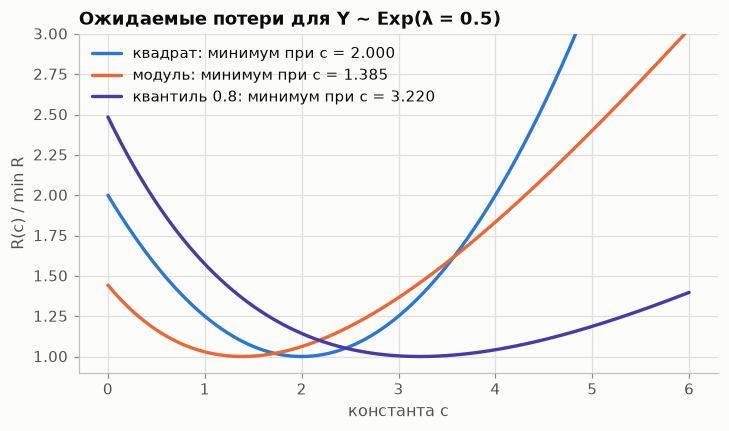

теория: среднее 2, медиана 1.3863 , 0.8-квантиль 3.2189
выборка из 20000: среднее 1.9798, медиана 1.3761, 0.8-квантиль 3.1938


In [17]:
y = np.linspace(0, 80, 400_001)
dy = y[1] - y[0]
p = lam * np.exp(-lam * y)
print("E Y =", np.sum(y * p) * dy, "(1/λ = 2);  D Y =", np.sum((y - 2)**2 * p) * dy, "(1/λ² = 4)")
cs = np.linspace(0, 6, 1201)
losses = {"квадрат": lambda c: (y - c)**2, "модуль": lambda c: np.abs(y - c),
          "квантиль 0.8": lambda c: np.where(y >= c, 0.8 * (y - c), 0.2 * (c - y))}
fig, ax = plt.subplots(figsize=(7.5, 4))
for (name, L), col in zip(losses.items(), [BLUE, ORANGE, VIOLET]):
    R = np.array([np.sum(L(c) * p) * dy for c in cs])
    ax.plot(cs, R / R.min(), color=col, lw=2.2, label=f"{name}: минимум при c = {cs[np.argmin(R)]:.3f}")
ax.set(xlabel="константа c", ylabel="R(c) / min R", ylim=(0.9, 3), title="Ожидаемые потери для Y ~ Exp(λ = 0.5)")
ax.legend()
plt.show()
print("теория: среднее 2, медиана", round(math.log(2) / lam, 4), ", 0.8-квантиль", round(-math.log(0.2) / lam, 4))
rng = Mulberry32(11)
sample = np.array([-math.log(1 - rng.random()) / lam for _ in range(20000)])
print(f"выборка из 20000: среднее {sample.mean():.4f}, медиана {np.median(sample):.4f}, 0.8-квантиль {np.quantile(sample, 0.8):.4f}")

### Шаг 27. AUC — площадь и вероятность

Оценки классов из $N(0, 1)$ и $N(1, 1)$; теория: $\text{AUC} = \Phi(1/\sqrt2) = 0.7602$.

площадь трапециями 0.758454, доля пар 0.758454, gbcourse 0.758454, теория 0.7602


sklearn roc_auc_score: 0.758454 ; пример из 4 объектов: 0.75


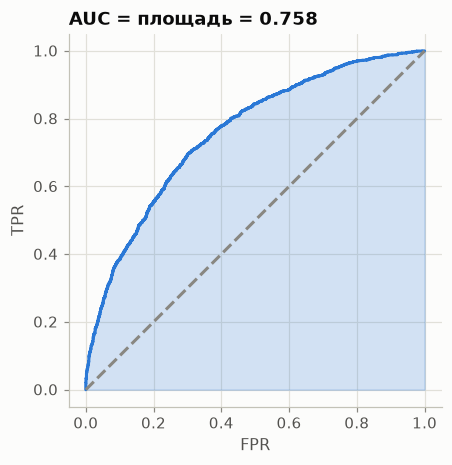

In [18]:
rng = Mulberry32(7)
n = 2000
yy = np.r_[np.zeros(n), np.ones(n)]
score = np.array([rng.normal(0, 1) for _ in range(n)] + [rng.normal(1, 1) for _ in range(n)])
order = np.argsort(-score)
tpr = np.r_[0, np.cumsum(yy[order] == 1) / n]
fpr = np.r_[0, np.cumsum(yy[order] == 0) / n]
area = float(np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2))
pairs = float((score[n:][:, None] > score[:n][None, :]).mean())
print(f"площадь трапециями {area:.6f}, доля пар {pairs:.6f}, gbcourse {metrics.roc_auc(yy, score):.6f}, теория {Phi(1 / math.sqrt(2)):.4f}")
from sklearn.metrics import roc_auc_score  # noqa: E402

print("sklearn roc_auc_score:", round(roc_auc_score(yy, score), 6), "; пример из 4 объектов:", roc_auc_score([0, 0, 1, 1], [0.7, 0.2, 0.9, 0.6]))

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.fill_between(fpr, 0, tpr, color=BLUE, alpha=0.2)
ax.plot(fpr, tpr, color=BLUE, lw=2)
ax.plot([0, 1], [0, 1], "--", color=MUTED)
ax.set(xlabel="FPR", ylabel="TPR", aspect="equal", title=f"AUC = площадь = {area:.3f}")
plt.show()

### Шаг 28. Интегрированные градиенты и полнота

In [19]:
F = lambda x: sig(1.5 * x[0] + x[1] + 2 * x[0] * x[1] - 1)  # noqa: E731


def grad_F(x):
    q = F(x)
    return q * (1 - q) * np.array([1.5 + 2 * x[1], 1 + 2 * x[0]])


base, xin = np.array([-1.0, -1.0]), np.array([1.2, 0.8])
for m in (1, 4, 16, 256):
    alphas = (np.arange(m) + 0.5) / m
    ig = (xin - base) * np.mean([grad_F(base + a * (xin - base)) for a in alphas], axis=0)
    print(f"m = {m:3d}: IG = {ig.round(5)}, сумма {ig.sum():.6f}")
print("F(x) − F(x′) =", round(F(xin) - F(base), 6), "; градиент × Δx =", round(grad_F(xin) @ (xin - base), 6))
# x₁x₂ из нуля: вклады поровну
a_, b_ = 1.5, 2.0
ig1 = a_ * quad(lambda al: al * b_, 0, 1)
print("x₁x₂: IG₁ = IG₂ =", ig1, "= ab/2; сумма", 2 * ig1, "= ab =", a_ * b_)

m =   1: IG = [0.57006 0.43053], сумма 1.000592
m =   4: IG = [0.45515 0.34513], сумма 0.800281
m =  16: IG = [0.45015 0.33984], сумма 0.789981
m = 256: IG = [0.44957 0.33926], сумма 0.788831
F(x) − F(x′) = 0.788826 ; градиент × Δx = 0.361311
x₁x₂: IG₁ = IG₂ = 1.5 = ab/2; сумма 3.0 = ab = 3.0


### Шаг 29. Бустинг с малым шагом — сумма Римана градиентного потока

ν = 1      M =     3: остаток (1 − ν)^M = 0.00000
ν = 0.5    M =     6: остаток (1 − ν)^M = 0.01562
ν = 0.1    M =    30: остаток (1 − ν)^M = 0.04239
ν = 0.01   M =   300: остаток (1 − ν)^M = 0.04904
ν = 0.001  M =  3000: остаток (1 − ν)^M = 0.04971
e^(−3) = 0.04979
ν = 1    : потери при t = 1, 2, 4: 0.1084, 0.0783, 0.0347
ν = 0.5  : потери при t = 1, 2, 4: 0.1133, 0.0566, 0.0316
ν = 0.2  : потери при t = 1, 2, 4: 0.1384, 0.0630, 0.0334
ν = 0.1  : потери при t = 1, 2, 4: 0.1451, 0.0661, 0.0348
ν = 0.05 : потери при t = 1, 2, 4: 0.1487, 0.0684, 0.0354
ν = 0.02 : потери при t = 1, 2, 4: 0.1514, 0.0693, 0.0359


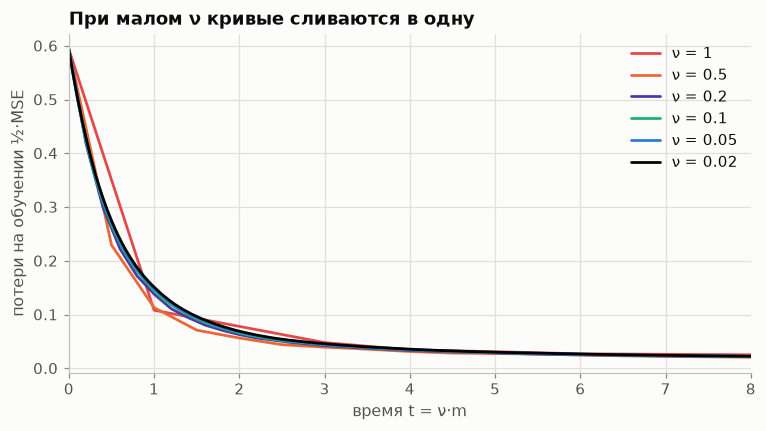

In [20]:
for nu in (1, 0.5, 0.1, 0.01, 0.001):
    print(f"ν = {nu:<6} M = {round(3 / nu):5d}: остаток (1 − ν)^M = {(1 - nu) ** round(3 / nu):.5f}")
print("e^(−3) =", round(math.exp(-3), 5))

Xb, yb = datasets.regression_1d(kind="wave", n=120, noise=0.3, seed=7)
fig, ax = plt.subplots(figsize=(8, 4))
for nu, col in zip((1, 0.5, 0.2, 0.1, 0.05, 0.02), (RED, ORANGE, VIOLET, AQUA, BLUE, "black")):
    M = round(8 / nu)
    model = GBRegressor(n_estimators=M, learning_rate=nu, max_depth=2).fit(Xb, yb)
    h = np.array(model.history_["train"])
    ax.plot(np.arange(M + 1) * nu, h, color=col, lw=1.8, label=f"ν = {nu}")
    print(f"ν = {nu:<5}: потери при t = 1, 2, 4: {h[round(1 / nu)]:.4f}, {h[round(2 / nu)]:.4f}, {h[round(4 / nu)]:.4f}")
ax.set(xlabel="время t = ν·m", ylabel="потери на обучении ½·MSE", xlim=(0, 8), title="При малом ν кривые сливаются в одну")
ax.legend()
plt.show()

## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ $\int_1^3 (2x + 1)\,dx$ формулой и как трапеция.
2. ★☆☆ Путь машины за первые и последние 5 секунд, средняя скорость.
3. ★☆☆ Сумма $1 + 2 + \dots + 200$ и $\sum_{k=1}^{20} k^2$.
4. ★★☆ Предел правых сумм для $\int_0^3 x^2\,dx$: формула $S_n$, сколько частей для ошибки < 0.01.
5. ★★☆ Производные интегралов с переменными пределами.
6. ★★☆ Замена и по частям: $\int_0^1 x e^{x^2} dx$, $\int_1^e x\ln x\,dx$, $\int_0^\infty x e^{-x} dx$.
7. ★★☆ Сколько частей нужно трапециям, серединам и Симпсону для точности $10^{-6}$ в $\int_0^1 e^x dx$; правило Рунге.
8. ★★☆ Сходимость $\int_1^\infty x^{-3/2}$, $\int_0^1 x^{-3/2}$, $\int_0^1 x^{-1/2}$.
9. ★★☆ Объём тела вращения $y = e^{-x}$ на $[0, \infty)$ и площадь под той же кривой.
10. ★★★ Монте-Карло: оценка $\pi$ и проверка закона $1/\sqrt n$.
11. ★★★ Лучшая константа для экспоненциального времени обслуживания при трёх функциях потерь.
12. ★★★ Докажите численно, что AUC равна вероятности $P(\text{оценка}_1 > \text{оценка}_0)$.